In [28]:

# CreditWise: Credit Score Classification using Machine Learning

#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# 📂 Load Dataset

In this section, we load the training and testing datasets and verify that they have been imported correctly.


In [29]:
# Load the datasets

train_df = pd.read_csv("../dataset/train.csv")
test_df = pd.read_csv("../dataset/test.csv")

print("Training dataset loaded successfully!")
print("Testing dataset loaded successfully!")

print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape  :", test_df.shape)

train_df.head()


Training dataset loaded successfully!
Testing dataset loaded successfully!
Training Dataset Shape : (100000, 28)
Testing Dataset Shape  : (50000, 27)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [30]:
# Column Names
print("Training Dataset Columns:\n")
print(train_df.columns.tolist())

# Dataset Information
train_df.info()

# Statistical Summary
train_df.describe().T


Training Dataset Columns:

['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  str    
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  str    
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  str    
 13  Type_of_Loan              88592 non-null   str    
 14  

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


In [31]:

# Categorical Summary
train_df.describe(include="object").T

,count,unique,top,freq
ID,100000,100000,0x1602,1
Customer_ID,100000,12500,CUS_0xd40,8
Month,100000,8,January,12500
Name,90015,10139,Langep,44
Age,100000,1788,38,2833
SSN,100000,12501,#F%$D@*&8,5572
Occupation,100000,16,_______,7062
Annual_Income,100000,18940,17273.83,16
Num_of_Loan,100000,434,3,14386
Type_of_Loan,88592,6260,Not Specified,1408


# Data Quality Assessment

Before cleaning the dataset, we inspect missing values, duplicate rows, invalid placeholders, and the target variable distribution.

In [32]:
missing_values = train_df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(train_df)) * 100
})

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Monthly_Inhand_Salary,15002,15.002
Type_of_Loan,11408,11.408
Name,9985,9.985
Credit_History_Age,9030,9.030
Num_of_Delayed_Payment,7002,7.002
Amount_invested_monthly,4479,4.479
Num_Credit_Inquiries,1965,1.965
Monthly_Balance,1200,1.200


In [33]:
print("Duplicate Rows :", train_df.duplicated().sum())

Duplicate Rows : 0


In [34]:
train_df["Credit_Score"].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

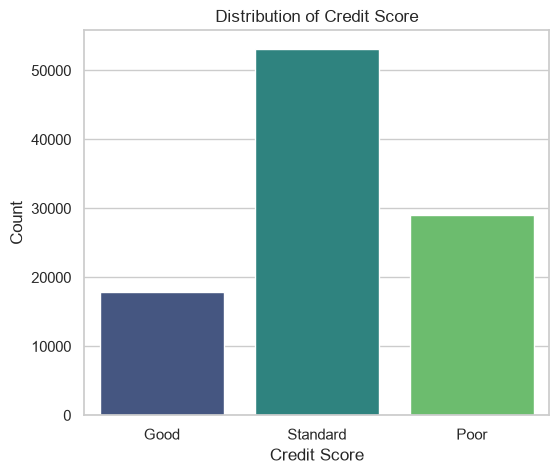

In [35]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=train_df,
    x="Credit_Score",
    palette="viridis"
)

plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Count")

plt.show()

In [36]:
train_df.dtypes

ID                              str
Customer_ID                     str
Month                           str
Name                            str
Age                             str
SSN                             str
Occupation                      str
Annual_Income                   str
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                     str
Type_of_Loan                    str
Delay_from_due_date           int64
Num_of_Delayed_Payment          str
Changed_Credit_Limit            str
Num_Credit_Inquiries        float64
Credit_Mix                      str
Outstanding_Debt                str
Credit_Utilization_Ratio    float64
Credit_History_Age              str
Payment_of_Min_Amount           str
Total_EMI_per_month         float64
Amount_invested_monthly         str
Payment_Behaviour               str
Monthly_Balance              object
Credit_Score                

In [37]:
for col in train_df.columns:
    print(f"\n{col}")
    print(train_df[col].unique()[:10])


ID
<StringArray>
['0x1602', '0x1603', '0x1604', '0x1605', '0x1606', '0x1607', '0x1608',
 '0x1609', '0x160e', '0x160f']
Length: 10, dtype: str

Customer_ID
<StringArray>
[ 'CUS_0xd40', 'CUS_0x21b1', 'CUS_0x2dbc', 'CUS_0xb891', 'CUS_0x1cdb',
 'CUS_0x95ee', 'CUS_0x284a', 'CUS_0x5407', 'CUS_0x4157', 'CUS_0xba08']
Length: 10, dtype: str

Month
<StringArray>
['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']
Length: 8, dtype: str

Name
<StringArray>
[  'Aaron Maashoh',               nan, 'Rick Rothackerj',          'Langep',
          'Jasond',          'Deepaa',              'Np',          'Nadiaq',
            'Annk',    'Charlie Zhur']
Length: 10, dtype: str

Age
<StringArray>
['23', '-500', '28_', '28', '34', '54', '55', '21', '31', '33']
Length: 10, dtype: str

SSN
<StringArray>
['821-00-0265',   '#F%$D@*&8', '004-07-5839', '486-85-3974', '072-31-6145',
 '615-06-7821', '612-70-8987', '411-51-0676', '500-92-6408', '070-19-1622']
Length: 10, dtype: str

Occupation

# Data Cleaning

## Remove Unnecessary Columns

Identifier columns do not contribute to credit score prediction and may introduce noise. Therefore, they are removed before further preprocessing.

In [38]:
# Create a copy of the training dataset
df = train_df.copy()

# Drop unnecessary columns
df.drop(
    columns=["ID", "Customer_ID", "Name", "SSN"],
    inplace=True
)

print("Dataset Shape after dropping columns:", df.shape)
df.head()

Dataset Shape after dropping columns: (100000, 24)


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,February,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,March,-500,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,April,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## Replace Invalid Placeholder Values

In [39]:
import numpy as np

df.replace({
    "Occupation": {"_______": np.nan},
    "Credit_Mix": {"_": np.nan},
    "Changed_Credit_Limit": {"_": np.nan},
    "Payment_Behaviour": {"!@9#%8": np.nan}
}, inplace=True)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,NaN,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,February,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,March,-500,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,NaN,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,April,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,April,25,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",23,7,11.5,3.0,NaN,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,May,25,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",18,7,11.5,3.0,NaN,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,June,25,Mechanic,39628.99,3359.415833,4,6,5729,2,"Auto Loan, and Student Loan",27,6,11.5,3.0,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,July,25,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",20,NaN,11.5,3.0,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [40]:
#Remove Underscores from Numeric Columns
numeric_string_columns = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in numeric_string_columns:
    df[col] = df[col].astype(str).str.replace("_", "", regex=False)

In [41]:
#Convert Numeric Columns to numbers.
numeric_columns = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Outstanding_Debt",
    "Changed_Credit_Limit",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  str    
 1   Age                       100000 non-null  int64  
 2   Occupation                92938 non-null   str    
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     84998 non-null   float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  int64  
 9   Type_of_Loan              88592 non-null   str    
 10  Delay_from_due_date       100000 non-null  int64  
 11  Num_of_Delayed_Payment    92998 non-null   float64
 12  Changed_Credit_Limit      97909 non-null   float64
 13  Num_Credit_Inquiries      98035 non-null   float64
 14  

## Handle Invalid Values

In [43]:
print("Negative Ages:", (df["Age"] < 0).sum())
print("Negative Loans:", (df["Num_of_Loan"] < 0).sum())
print("Negative Delay:", (df["Delay_from_due_date"] < 0).sum())
df.loc[df["Age"] < 0, "Age"] = np.nan
df.loc[df["Num_of_Loan"] < 0, "Num_of_Loan"] = np.nan
df.loc[df["Delay_from_due_date"] < 0, "Delay_from_due_date"] = np.nan
df.loc[(df["Age"] < 18) | (df["Age"] > 100), "Age"] = np.nan

Negative Ages: 886
Negative Loans: 3876
Negative Delay: 591


## Convert Credit History Age to Total Months

In [44]:
def convert_credit_history(age):
    if pd.isna(age):
        return np.nan

    parts = age.split()

    years = int(parts[0])
    months = int(parts[3])

    return years * 12 + months


df["Credit_History_Age"] = df["Credit_History_Age"].apply(convert_credit_history)



In [45]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  str    
 1   Age                       91518 non-null   float64
 2   Occupation                92938 non-null   str    
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     84998 non-null   float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               96124 non-null   float64
 9   Type_of_Loan              88592 non-null   str    
 10  Delay_from_due_date       99409 non-null   float64
 11  Num_of_Delayed_Payment    92998 non-null   float64
 12  Changed_Credit_Limit      97909 non-null   float64
 13  Num_Credit_Inquiries      98035 non-null   float64
 14  

Month                           0
Age                          8482
Occupation                   7062
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                  3876
Type_of_Loan                11408
Delay_from_due_date           591
Num_of_Delayed_Payment       7002
Changed_Credit_Limit         2091
Num_Credit_Inquiries         1965
Credit_Mix                  20195
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour            7600
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

## Handle Missing Values

Missing values in numerical features are filled using the median, while missing values in categorical features are filled using the mode. This preserves the overall distribution of the data and avoids losing valuable records.

In [46]:
# Numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [47]:
# Categorical columns
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [48]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age"].describe()

count    100000.000000
mean         34.393360
std           9.685699
min          18.000000
25%          27.000000
50%          34.000000
75%          41.000000
max         100.000000
Name: Age, dtype: float64

In [49]:
df.isnull().sum()

Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

In [50]:
# Save cleaned training dataset
df.to_csv("../cleaned_data/train_cleaned.csv", index=False)

print("Cleaned training dataset saved successfully!")

Cleaned training dataset saved successfully!


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution of features, identify trends, and analyze relationships between financial attributes and credit score categories.

### Observation

The dataset is moderately imbalanced, with the **Standard** credit score category having the highest number of records, followed by **Poor** and **Good**.

## Age Distribution

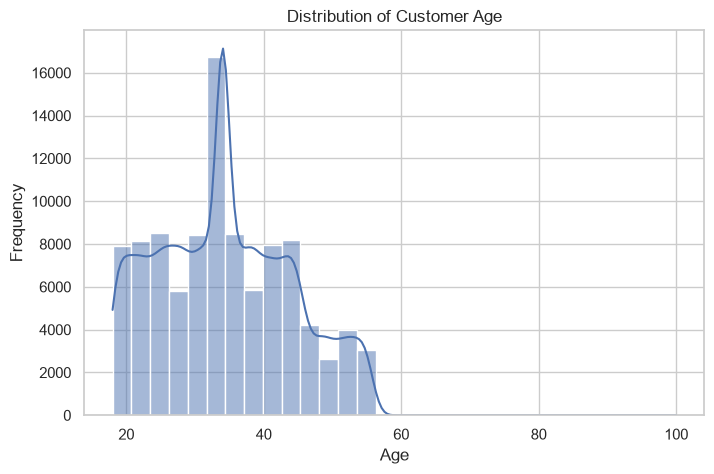

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation

Most customers fall within the young to middle-aged category, indicating that the dataset primarily represents working-age individuals.

In [27]:
df["Age"].describe()

count    100000.000000
mean        115.372080
std         683.856027
min          14.000000
25%          25.000000
50%          33.000000
75%          42.000000
max        8698.000000
Name: Age, dtype: float64

## Annual Income Distribution

The following visualization shows the distribution of customers' annual income.

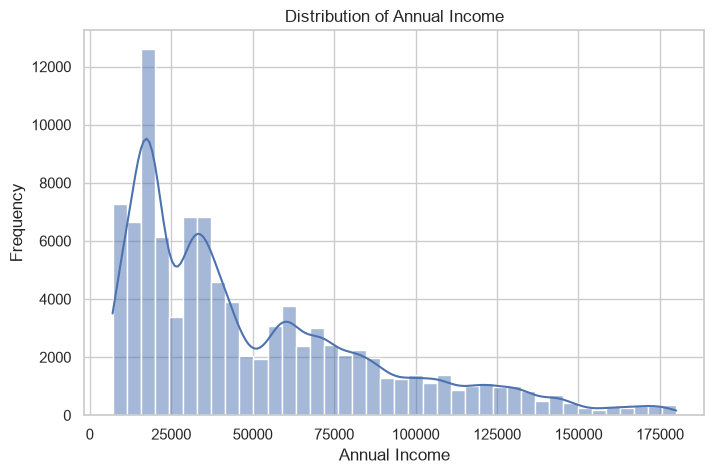

In [55]:
upper_limit = df["Annual_Income"].quantile(0.99)

plt.figure(figsize=(8,5))

sns.histplot(
    df[df["Annual_Income"] <= upper_limit]["Annual_Income"],
    bins=40,
    kde=True
)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()

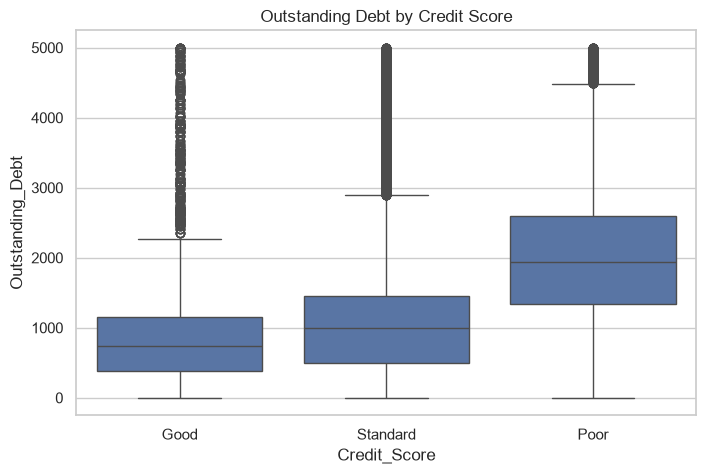

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Credit_Score",
    y="Outstanding_Debt",
    data=df
)

plt.title("Outstanding Debt by Credit Score")

plt.show()

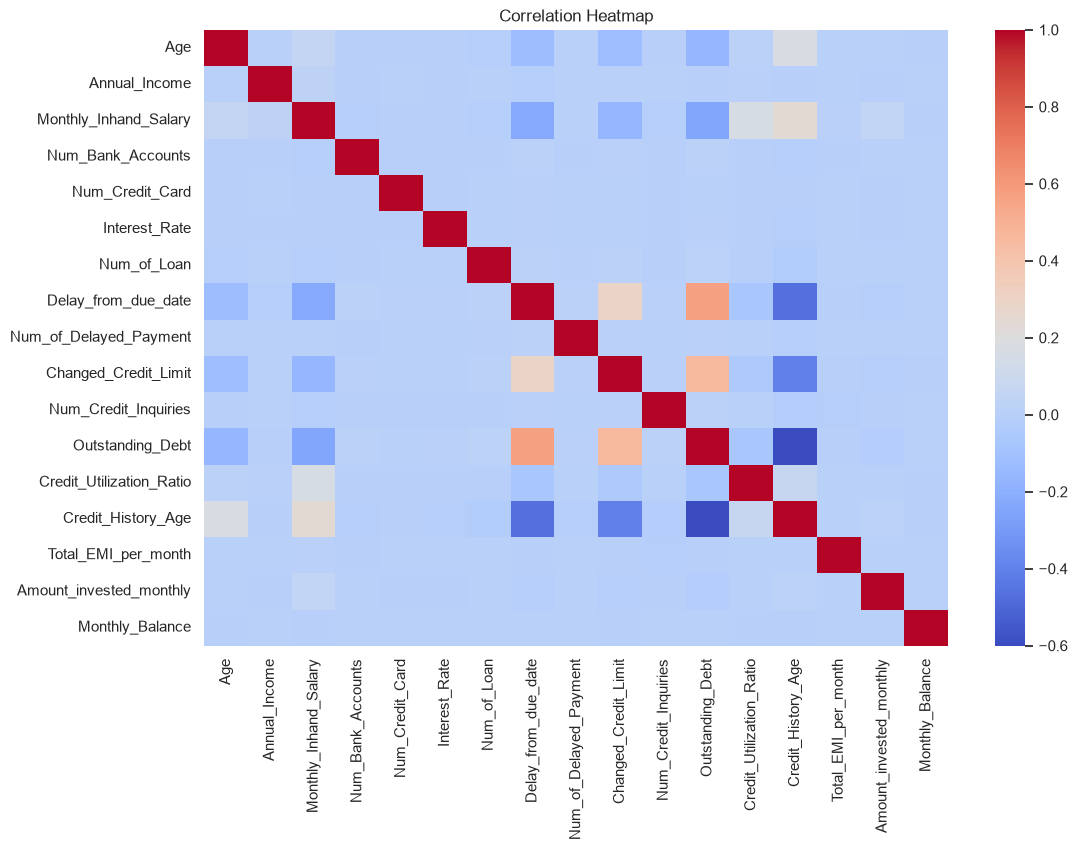

In [57]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

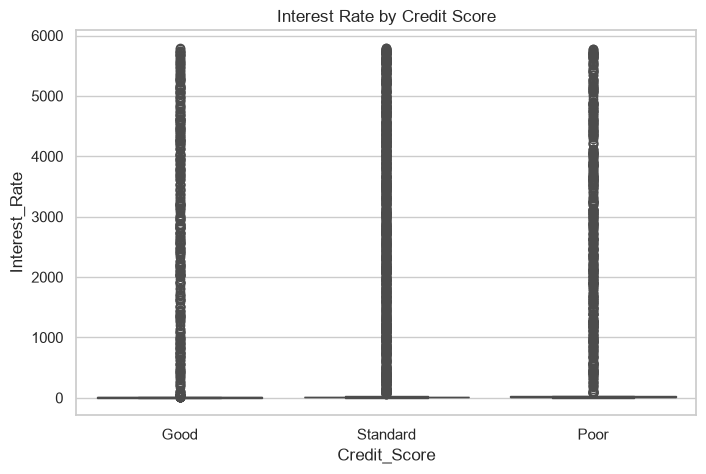

In [59]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Credit_Score",
    y="Interest_Rate",
    data=df
)

plt.title("Interest Rate by Credit Score")

plt.show()

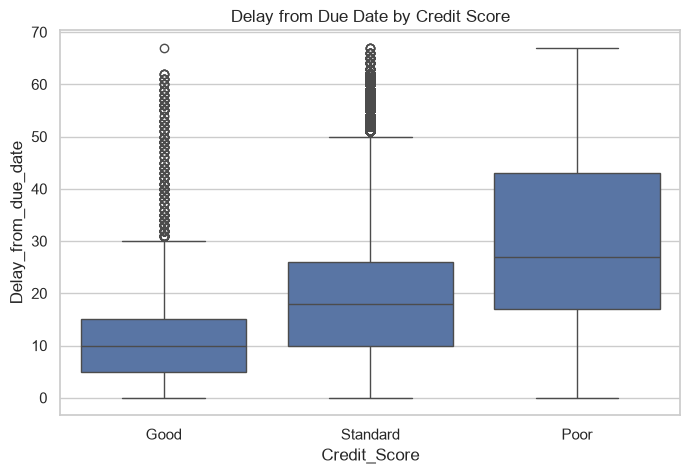

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Credit_Score",
    y="Delay_from_due_date",
    data=df
)

plt.title("Delay from Due Date by Credit Score")

plt.show()

# Conclusion

The dataset was successfully cleaned and preprocessed by handling missing values, correcting invalid entries, converting data types, and performing exploratory data analysis. The cleaned dataset was saved for model training.